In [1]:
import pandas as pd

In [45]:
altin_data = pd.read_excel('gram_altin_tamamen_ham.xlsx')
df = altin_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Tarih    1459 non-null   object
 1   Acilis   1459 non-null   object
 2   Kapanis  1459 non-null   object
dtypes: object(3)
memory usage: 34.3+ KB


In [47]:
df.head()

,Tarih,Acilis,Kapanis
0,7 Aralık 2020,"461,28","468,03"
1,8 Aralık 2020,"468,00","470,31"
2,9 Aralık 2020,"467,58","462,15"
3,10 Aralık 2020,"462,52","465,70"
4,11 Aralık 2020,"465,67","463,62"


In [55]:
print(df.sample(15))

                Tarih    Acilis   Kapanis
255      15 Ekim 2021    529,69    525,98
1325   4 Haziran 2025  4.221,89  4.247,00
236     23 Eylül 2021    491,55    490,80
910      1 Kasım 2023  1.804,73  1.804,97
902      20 Ekim 2023  1.776,00  1.780,41
634     22 Kasım 2022  1.041,37  1.041,47
919     14 Kasım 2023  1.807,92  1.807,95
489   29 Haziran 2022    972,92    972,94
198    9 Ağustos 2021    488,45    479,91
639     27 Kasım 2022      0,00  1.051,84
458     28 Mayıs 2022    972,64    965,28
877     15 Eylül 2023  1.654,18  1.669,39
728     26 Şubat 2023  1.106,66  1.099,08
1125  28 Ağustos 2024  2.759,84  2.741,18
631     19 Kasım 2022  1.053,02  1.046,41


In [71]:
df['Acilis'].apply(lambda x : x.replace('.', '')).tail() #Noktaları kaldırdım doğru oluyomu diye bakicam

1454    5764,63
1455    5781,25
1456    5745,21
1457    5740,34
1458    5753,02
Name: Acilis, dtype: object

In [73]:
df.Acilis = df['Acilis'].apply(lambda x : x.replace('.', ''))

In [77]:
df['Acilis'].apply(lambda x : x.replace(',', '.')) #Kontrol için

0        461.28
1        468.00
2        467.58
3        462.52
4        465.67
         ...   
1454    5764.63
1455    5781.25
1456    5745.21
1457    5740.34
1458    5753.02
Name: Acilis, Length: 1459, dtype: object

In [79]:
df.Acilis = df['Acilis'].apply(lambda x : float(x.replace(',', '.')))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tarih    1459 non-null   object 
 1   Acilis   1459 non-null   float64
 2   Kapanis  1459 non-null   object 
dtypes: float64(1), object(2)
memory usage: 34.3+ KB


In [85]:
def coverFloat(data):
    data = data.replace('.', '')
    return float(data.replace(',', '.'))

df.Kapanis = df['Kapanis'].apply(coverFloat)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tarih    1459 non-null   object 
 1   Acilis   1459 non-null   float64
 2   Kapanis  1459 non-null   float64
dtypes: float64(2), object(1)
memory usage: 34.3+ KB


In [115]:
aylar = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# Tarih sütunundaki ay isimlerini değiştirme
for tr, num in aylar.items():
    df['Tarih'] = df['Tarih'].str.replace(tr, num, regex=False)

# 2. Datetime formatına çevirme (Gün Ay Yıl formatında olduğu için dayfirst=True)
# Artık format "15 10 2021" gibi oldu, bunu datetime'a çeviriyoruz.
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tarih    1459 non-null   datetime64[ns]
 1   Acilis   1459 non-null   float64       
 2   Kapanis  1459 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 34.3 KB
None


In [117]:
df.head(15)

,Tarih,Acilis,Kapanis
0,2020-12-07,461.28,468.03
1,2020-12-08,468.00,470.31
2,2020-12-09,467.58,462.15
3,2020-12-10,462.52,465.70
4,2020-12-11,465.67,463.62
5,2020-12-12,465.63,463.62
6,2020-12-14,464.20,461.52
7,2020-12-15,461.70,467.22
8,2020-12-16,467.22,467.63
9,2020-12-17,467.82,466.69


In [119]:
def ml_icin_hazirla(df):
    # Tarihi parçalarına ayırıyoruz ki model (Random Forest vb.) anlayabilsin
    df['Yil'] = df['Tarih'].dt.year
    df['Ay'] = df['Tarih'].dt.month
    df['Gun'] = df['Tarih'].dt.day
    df['HaftaninGunu'] = df['Tarih'].dt.dayofweek # 0: Pzt, 6: Paz
    
    # İPUCU: Finans verisinde "Lag" (Gecikmeli) özellikler model başarısını çok artırır.
    # "Bugünün fiyatını tahmin etmek için dünün kapanış fiyatını kullan" mantığı.
    df['Dunku_Kapanis'] = df['Kapanis'].shift(1)
    
    # İlk satırda "dün" olmadığı için NaN oluşur, siliyoruz
    df = df.dropna()
    
    return df

In [121]:
ml_icin_hazirla(df)

,Tarih,Acilis,Kapanis,Yil,Ay,Gun,HaftaninGunu,Dunku_Kapanis
1,2020-12-08,468.00,470.31,2020,12,8,1,468.03
2,2020-12-09,467.58,462.15,2020,12,9,2,470.31
3,2020-12-10,462.52,465.70,2020,12,10,3,462.15
4,2020-12-11,465.67,463.62,2020,12,11,4,465.70
5,2020-12-12,465.63,463.62,2020,12,12,5,463.62
...,...,...,...,...,...,...,...,...
1454,2025-12-01,5764.63,5781.31,2025,12,1,0,5763.55
1455,2025-12-02,5781.25,5745.87,2025,12,2,1,5781.31
1456,2025-12-03,5745.21,5740.46,2025,12,3,2,5745.87
1457,2025-12-04,5740.34,5753.00,2025,12,4,3,5740.46


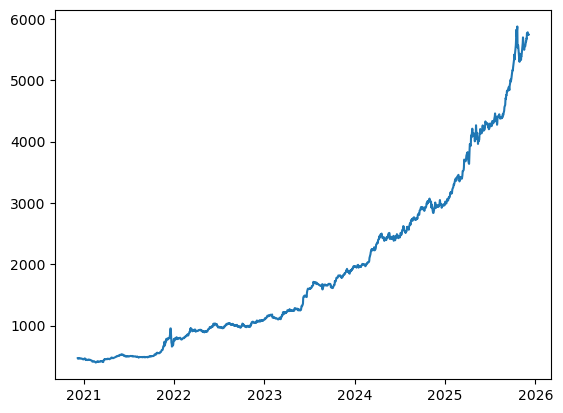

In [127]:
import matplotlib.pyplot as plt
plt.plot(df['Tarih'], df['Kapanis'])

In [131]:
df.set_index('Tarih').resample('M').mean()[['Acilis', 'Kapanis']]

/var/folders/22/j5k7n31s4p1fkq4x0frr3myc0000gn/T/ipykernel_17233/2926793234.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Tarih').resample('M').mean()[['Acilis', 'Kapanis']]


,Acilis,Kapanis
Tarih,,
2020-12-31,461.339524,460.786667
2021-01-31,444.649200,443.000000
2021-02-28,413.074167,411.807500
2021-03-31,424.401852,424.427778
2021-04-30,460.896667,461.453750
...,...,...
2025-08-31,4411.668571,4424.358095
2025-09-30,4840.295217,4869.129565
2025-10-31,5195.432174,5459.862174


In [167]:
X = df[['Yil', 'Ay', 'Gun', 'HaftaninGunu', 'Dunku_Kapanis']]
y = df.Kapanis

In [137]:
# 2. Train - Test Ayrımı (SHUFFLE = FALSE Çok Önemli!)
# Verinin %80'i eğitim, %20'si test
split_point = int(len(df) * 0.8)

In [169]:
X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

In [171]:
print(f"Eğitim Verisi: {X_train.shape[0]} satır")
print(f"Test Verisi: {X_test.shape[0]} satır")

Eğitim Verisi: 1167 satır
Test Verisi: 291 satır


In [173]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, seed=42)
}

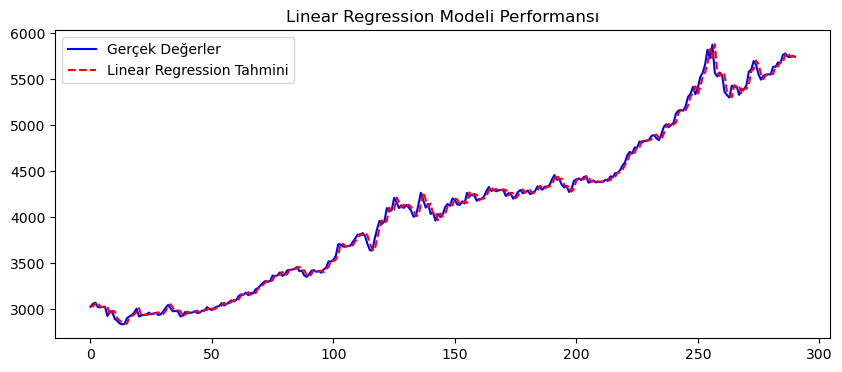

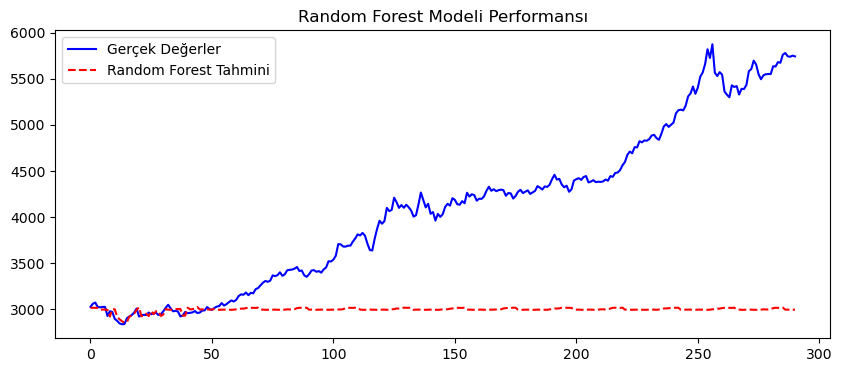

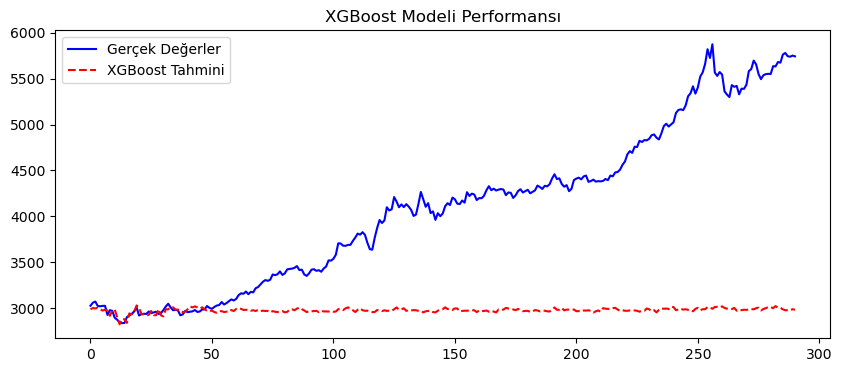

In [177]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 4. Döngü ile Modelleri Eğitip Sonuçları Kaydetme
results = []

for name, model in models.items():
    # Modeli Eğit
    model.fit(X_train, y_train)
    
    # Tahmin Yap
    predictions = model.predict(X_test)
    
    # Metrikleri Hesapla
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "MAE (Ort. Hata TL)": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (Başarı)": round(r2, 4)
    })
    
    # Grafik Çiz (Opsiyonel ama Rapor için harika olur)
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.values, label='Gerçek Değerler', color='blue')
    plt.plot(predictions, label=f'{name} Tahmini', color='red', linestyle='--')
    plt.title(f'{name} Modeli Performansı')
    plt.legend()
    plt.show()

In [179]:
results_df = pd.DataFrame(results)
print("\n--- MODEL KARŞILAŞTIRMA TABLOSU ---")
print(results_df.sort_values(by="R2 Score (Başarı)", ascending=False))


--- MODEL KARŞILAŞTIRMA TABLOSU ---
               Model  MAE (Ort. Hata TL)     RMSE  R2 Score (Başarı)
0  Linear Regression               36.13    51.64             0.9965
1      Random Forest             1099.32  1393.14            -1.5578
2            XGBoost             1117.28  1406.55            -1.6073


In [183]:
# 1. Veriyi Prophet Formatına Hazırlama
# Prophet katı kurallıdır: Tarih sütunu -> 'ds', Hedef sütun -> 'y' olmalı.
df_prophet = df[['Tarih', 'Kapanis']].copy()
df_prophet.columns = ['ds', 'y']

In [185]:
df_prophet.head()

,ds,y
1,2020-12-08,470.31
2,2020-12-09,462.15
3,2020-12-10,465.70
4,2020-12-11,463.62
5,2020-12-12,463.62


In [187]:
# 2. Train - Test Ayrımı (Yine karıştırmadan, son %20 test)
split_point = int(len(df_prophet) * 0.8)
train = df_prophet.iloc[:split_point]
test = df_prophet.iloc[split_point:]

In [191]:
from prophet import Prophet

In [189]:
# 3. Modeli Kurma ve Eğitme
# daily_seasonality=True: Finans verisi olduğu için günlük değişimler önemli
model_prophet = Prophet(daily_seasonality=True, yearly_seasonality=True) 

model_prophet.fit(train)

17:04:23 - cmdstanpy - INFO - Chain [1] start processing
17:04:24 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
# 4. Tahmin Yapma
# Test seti uzunluğunda bir "gelecek" dataframe'i oluşturmamıza gerek yok,
# direkt test setindeki tarihleri verip tahmin isteyebiliriz.
forecast = model_prophet.predict(test[['ds']])

In [195]:
# 5. Metrikleri Hesaplama
y_true = test['y'].values
y_pred = forecast['yhat'].values # Prophet tahmin sonucuna 'yhat' der

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"--- Prophet Modeli Sonuçları ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

--- Prophet Modeli Sonuçları ---
MAE  : 447.92
RMSE : 575.49
R2   : 0.5642


4 Model arasından yapılan en bşarılı model göründüğü gibi Linear Regression. Yolumuza demek ki onunla devam edicez.

In [198]:
pd.to_csv(

,Tarih,Acilis,Kapanis,Yil,Ay,Gun,HaftaninGunu,Dunku_Kapanis
1,2020-12-08,468.00,470.31,2020,12,8,1,468.03
2,2020-12-09,467.58,462.15,2020,12,9,2,470.31
3,2020-12-10,462.52,465.70,2020,12,10,3,462.15
4,2020-12-11,465.67,463.62,2020,12,11,4,465.70
5,2020-12-12,465.63,463.62,2020,12,12,5,463.62
